will check generated from retrieved is hallucinating or not - gen answer is fully/partially/not supported

## Loading API Key

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

## Loading Necessary Libraries

In [5]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

## Initial Basic Steps
- Document Loading
- Chunking 
- Embedding
- Storing to VectorDB 
- Creation of Retriever Object for Further Use
- LLM Object Creation

In [6]:
docs = DirectoryLoader(
    path = 'documents', 
    glob = '*.pdf',
    loader_cls = PyPDFLoader
).load()

In [7]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150).split_documents(docs)
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

- For chunking, values for parameters `chunk_size` and `chunk_overlap` is experimentally got here.

In [8]:
retriever = vector_store.as_retriever(search_kwargs = {'k': 4})

- Here as we set `k` to `4`, post retrieval 4 relevant documents will be shared where retrieval is required.

In [9]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

## Define State
- `state` is a class which carries variables and their values at different steps of the workflow.
- Variables in `state` are modified as workflow proceeds.
- Variables:
    - `question`: user query
    - `need_retrieval`: boolean parameter indicating retrieval of documents is needed or not for particular query going to vector database
    - `docs`: list of all retrieved docs
    - `relevant_docs`: list of relevant documents
    - `answer`: final answer which will be showed to user
    - `context`: cosolidated documents from relevant documents to send in prompt for answer generation where query requires document retrieval
    - `issup`: boolean parameter indicating RAG generated answer is grounded in relevant documents or not
    - `evidence`: list of strings from relevant documents which supports the answer in case of fully/partially supported

- Can add description in schema itself.
- Here `issup` and `evidence` are newly added in `state` of the workflow for post generation verification.

In [10]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    
    docs: List[Document]
    relevant_docs: list[Document]

    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidencee: List[str]

## Decision on Requirement of Retrival of Documents
- This below part is to output schema of structured LLM , prompt and node regarding query needs RAG or LLM can answer from its parametric knowledge.

#### Output Schema for Node `decide_retrieval`
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [11]:
class RetrieveDecicision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False"
    )

#### Prompt for Node `decide_retrieval`

In [12]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve = True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve = False for general explanations, definitions, or reasoning taht doesn't need sources.\n"
            "- If unsure. choose True."
        ),
        ("human", "Question: {question}")
    ]
)

#### Structured LLM for Node `decide_retrieval`
- **`IMPORTANT`**: NO `.content` for structured output.

In [13]:
should_retrieve_llm = llm.with_structured_output(RetrieveDecicision)

#### Define Node `decide_retrieval`

In [14]:
def decide_retrieval(state: "State"):
    decision: RetrieveDecicision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question = state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

## Direct Answer Generation
- Below part will generate answer for queries which can be answered by LLM directly without retrieving  document.

#### Prompt for `generate_direct`

In [15]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specifics sources, say:\n"
            "I don't know based on my general knowledge."
        ),
        ("human", "{question}")
    ]
)

#### Define Node `generate_direct`

In [16]:
def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question = state["question"]
        )
    )
    return {
        "answer": out.content
    }

## Retrieval of Documents
- Node `retrieve` will retrieve document where required.
#### Define Node `retrieve`
- This nodes does not require any output schema or prompt.
- It just needs `retriever` object defined in `Initial Basic Steps`.
- This node will be used in case `decide_retrieval` decides that query requires to retrieve document. 

#### Output Schema of Required Structured LLM
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [17]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

## Evaluation of Relevance of Retrieved Documents
#### Output Schema for Node `is_relevant`
- It is working with LLM with output schema `RelevanceDecision` which is having a boolean variable which tells relevant or not.

In [18]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "true if the documment helps answer the question, else False."
    )

#### Prompt for Node `is_relevant`

In [19]:
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a judging document relavance.\n"
            "Return the JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        )
    ]
)

#### Structured LLM for Node `is_relevant`

In [20]:
relevance_llm = llm.with_structured_output(RelevanceDecision)

#### Define Node `is_relevant`
- This node present will decide relevance of retrieved documents.

In [21]:
def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = state["question"],
                document = doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

## Generating Answer by RAG
#### Prompt for Node `generate_from_context`

In [22]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        )
    ]
)

#### Define Node `generate_from_context`
- The `generate_from_context` node present in below section will generate answer based on relevant documents + prompt.

In [23]:
def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()
    
    if not context:
        return {"answer": "No answer found.", "context": ""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state["question"],
            context = context
        )
    )
    return {"answer": out.content, "context": context}

#### Define Node `no_relevant_docs`

In [24]:
def no_relevant_docs(satte: State):
    return {"answer": "No answer found.", "context":""}

## Checking Hallucination of RAG Generated Answer

#### Output Schema for Node `is_sup`

In [25]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

#### Prompt for Node `is_sup`

In [26]:
issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

#### Structured Output LLM for Node `is_sup`

In [27]:
issup_llm = llm.with_structured_output(IsSUPDecision)

#### Define Node `is_sup`

In [28]:
def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

## Routing Node Function 
- `route_after_decide` will decide to retrieve documents or directly send query to answer generating LLM.
- This will work based on output of `decide_retrieval`.

In [29]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

- `route_after_relevance` will decide next node based on presence of relevant documents.

In [30]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_relevant_docs"

## Define Graph
-  `retrieve` node is temporary end for retrieval path, as reasons discussed earlier.

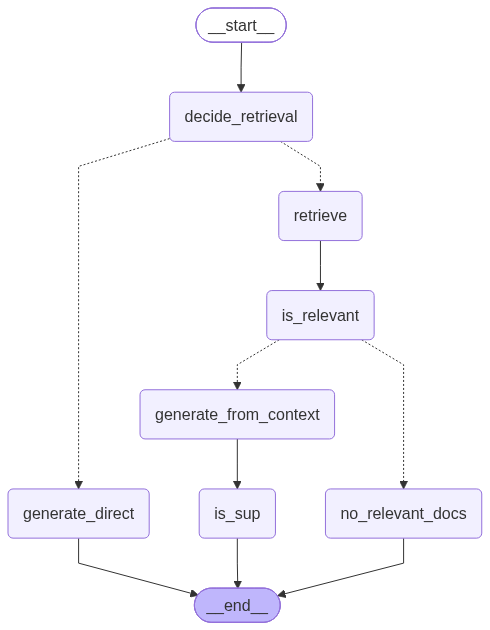

In [31]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)

g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)


g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs"
    },
)

# If no relevant docs found, end
g.add_edge("no_relevant_docs", END)

# If generated from context, verify with IsSUP loop
g.add_edge("generate_from_context", "is_sup")
g.add_edge("is_sup", END)

app = g.compile()
app

## Test on Questions
- Now we will see implementation till here with few questions.

#### Question - 1:

In [32]:
result1 = app.invoke(
    {
        "question": 'Who is the CEO of Noventra Systems?',
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [33]:
print("need_retrieval:", result1.get("need_retrieval"))
print("#docs:", len(result1.get("docs", [])))
print("#relevant_docs:", len(result1.get("relevant_docs", [])))
print("issup:", result1.get("issup"))
print("evidence:", result1.get("evidence"))
print("answer:", result1.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: None
answer: The CEO of Noventra Systems is Dr. Arjun Mehta.


In [44]:
for doc in result1["relevant_docs"]:
    print(doc.page_content)
    print("*"*100)

assistants, workflow automation, analytics platforms, and enterprise collaboration software. 
Today, Noventra serves customers in more than 25 countries through regional offices and partner 
networks. 
 
Founders 
Dr. Arjun Mehta 
Founder & Chief Executive Officer (CEO) 
Dr. Mehta previously led enterprise AI research initiatives and has over 18 years of experience in 
artificial intelligence and cloud technologies. 
 
Priya Raman 
Co-Founder & Chief Product Officer (CPO) 
Priya oversees product strategy, customer experience, and long-term product roadmap. 
 
Ethan Brooks
****************************************************************************************************


#### Question - 2:

In [42]:
result2 = app.invoke(
    {
        "question": 'How many countries employees of Noventra Systems belong to?',
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [43]:
print("need_retrieval:", result2.get("need_retrieval"))
print("#docs:", len(result2.get("docs", [])))
print("#relevant_docs:", len(result2.get("relevant_docs", [])))
print("issup:", result2.get("issup"))
print("evidence:", result2.get("evidence"))
print("answer:", result2.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 1
issup: no_support
evidence: None
answer: No relevant document found.


In [36]:
for doc in result2["relevant_docs"]:
    print(doc.page_content)
    print("*"*100)

#### Question - 3:

In [45]:
result3 = app.invoke(
    {
        "question": "Does Noventra Systems plans include a free trial? If yes, how many days?",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [46]:
print("need_retrieval:", result3.get("need_retrieval"))
print("#docs:", len(result3.get("docs", [])))
print("#relevant_docs:", len(result3.get("relevant_docs", [])))
print("issup:", result3.get("issup"))
print("evidence:", result3.get("evidence"))
print("answer:", result3.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 0
issup: 
evidence: None
answer: No answer found.


#### Question - 4:

In [49]:
result4 = app.invoke(
    {
        "question": "Describe Noventra Systems's company culture",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [50]:
print("need_retrieval:", result4.get("need_retrieval"))
print("#docs:", len(result4.get("docs", [])))
print("#relevant_docs:", len(result4.get("relevant_docs", [])))
print("issup:", result4.get("issup"))
print("evidence:", result4.get("evidence"))
print("answer:", result4.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 3
issup: fully_supported
evidence: None
answer: Noventra Systems's company culture promotes flexible working, continuous learning, an inclusive workplace, cross-functional collaboration, and innovation through experimentation. The company emphasizes employee wellbeing and encourages teamwork across departments and with customers. Accountability is valued, with an expectation for employees to take ownership of their commitments and continuously improve outcomes. Additionally, there is a strong focus on promoting continuous skill development and experimentation among employees. The company is committed to creating a respectful, inclusive, and growth-oriented workplace.


#### Question - 5:

In [51]:
result5 = app.invoke(
    {
        "question": "Does Noventra Systems plans include a free trial? If yes, how many days?",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": []
    }
)

In [52]:
print("need_retrieval:", result5.get("need_retrieval"))
print("#docs:", len(result5.get("docs", [])))
print("#relevant_docs:", len(result5.get("relevant_docs", [])))
print("issup:", result5.get("issup"))
print("evidence:", result5.get("evidence"))
print("answer:", result5.get("answer"))

need_retrieval: True
#docs: 4
#relevant_docs: 0
issup: 
evidence: None
answer: No answer found.


## TODO:
- Here for the query `Can employees take leaves in durga puja in Novantra?`, it's known festival, so we can extend the solution either here or in future while putting self-rag in any usecase, can keep a  node that if this type of questions come where llm can answer from parameter or websearch (bt rewriting query) for general knoledge part to know that durga puja is a festival and either there will be public holiday or people take take pre-planned leave and in doc it is seeing employees can take casual leave so combining it can say employees can take if not public holiday, also we can provide holiday list to answer better. See this is correct to do or not as in video we saw from two chunks '24 paid leaves' and 'employees can take sick leave and casual leave' if LLM will answer '24 paid leaves which contains sick and casual' is tagged as fabricated. 
- We can implement usefulness check for queries which do not need document retrieval and directly goes to LLM for answer generation.
- From `no_relevant_docs` node, we can go for web search if usecase permits and making sense. E.g. - if it is company specific query but topic is public suppose `How much is comapny XYZ's revenue and profit last year?` This answer is publically available. So if it is not in shared documents, it can be fetched from web_search and answer to user.
- Here we can find examples to see all three types of supports: `fully_supported`, `partially_suppoorted`, `no_supported`.
- In above questions where answer is fully suported, evidence is showing as `none`, it should not be the case, evidence should show strings supporting answer.
- We should understand this behaviour.